In [1]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.genmod.families import NegativeBinomial
from scipy.special import logit, expit
import pandas as pd

In [2]:
analysis_data_dir = r"../../Data/AnalysisData/sensitivity_analysis_data.csv"
df_overall_model = pd.read_csv(analysis_data_dir)
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]]
df_overall_model.to_csv("sensitivity_analysis_data_for_R.csv")
df_overall_model["identifier"] = "treatment"

time_keys = ["CALL_DURATION", "TIME_DELAY_FOR_DIRECTION_CHANGE", "BAT_RADIAL_RESOLUTION"]
df_overall_model[time_keys] = df_overall_model[time_keys]*1000 # to make seconds into ms

In [3]:
def center_df(df):
    centered_df=(df-df.mean())/df.std()
    return centered_df

In [17]:
varying_params = np.array([
    "BAT_SPEED",
    "CALL_DURATION",
    "CALL_RATE_FAST",
    "HEARING_THRESHOLD",
    "CALL_DIRECTIONALITY",
    "TEMPORAL_MASKING_FN_TYPE",
    "TIME_DELAY_FOR_DIRECTION_CHANGE",
    "BAT_RADIAL_RESOLUTION",
    "MEMORY_WINDOW_FOR_CONSISTENCY",
    "BAT_FRONTAL_RANGE",
])
df_overall_model["TEMPORAL_MASKING_FN_TYPE_ONE_HOT"] = [1 if i=="full" else 0 for i in df_overall_model["TEMPORAL_MASKING_FN_TYPE"]] 

In [5]:
store_regression_coef = []
store_hue_label = []
store_param_label = []

centered_df = df_overall_model.copy()
predictors = centered_df[varying_params]
centered_df[varying_params] = center_df(predictors)
response_variables = centered_df["collision_counts"]

centered_df
df_overall_model

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment


In [6]:
df = centered_df.copy()

formula = """
collision_counts ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST +
HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT +
TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION +
MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE
"""

In [7]:
poisson_model = smf.glm(formula=formula, data=df, family=sm.families.Poisson()).fit()

# Calculate dispersion parameter
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
alpha = 1/dispersion  # Initial estimate for Negative Binomial alpha

print(f"Estimated dispersion: {dispersion:.4f}")
print(f"Initial alpha estimate: {alpha:.4f}")

Estimated dispersion: 3.0479
Initial alpha estimate: 0.3281


In [18]:
import statsmodels.formula.api as smf
from statsmodels.genmod.families import NegativeBinomial
import pandas as pd

# Convert all predictors to categorical (one-hot encoding)
df_cat = df_overall_model.copy()
for col in predictors:
    df_cat[col] = pd.Categorical(df_cat[col])

# Define formula with all categorical variables
formula = """
collision_counts ~ C(BAT_SPEED) + C(CALL_DURATION) + C(CALL_RATE_FAST) +
C(HEARING_THRESHOLD) + C(CALL_DIRECTIONALITY) +
C(TEMPORAL_MASKING_FN_TYPE) + C(TIME_DELAY_FOR_DIRECTION_CHANGE) +
C(BAT_RADIAL_RESOLUTION) + C(MEMORY_WINDOW_FOR_CONSISTENCY) + C(BAT_FRONTAL_RANGE)
"""

# First fit Poisson to estimate dispersion
poisson_model = smf.glm(formula=formula, data=df_cat, family=sm.families.Poisson()).fit()
pearson_resid = poisson_model.resid_pearson
dispersion = np.sum(pearson_resid**2) / poisson_model.df_resid
alpha = 1/dispersion

# Fit Negative Binomial with categorical variables
model_nb = smf.glm(
    formula=formula,
    data=df_cat,
    family=NegativeBinomial(alpha=alpha)
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

NEGATIVE BINOMIAL MODEL (COLLISION COUNTS - ALL CATEGORICAL)
                             Results: Generalized linear model
Model:                       GLM                      AIC:                    832734.5708  
Link Function:               Log                      BIC:                    -1704339.5183
Dependent Variable:          collision_counts         Log-Likelihood:         -4.1635e+05  
Date:                        2026-03-12 18:18         LL-Null:                -5.4389e+05  
No. Observations:            155520                   Deviance:               1.5464e+05   
Df Model:                    15                       Pearson chi2:           1.85e+05     
Df Residuals:                155504                   Scale:                  1.0000       
Method:                      IRLS                                                          
-------------------------------------------------------------------------------------------
                                            Coef

In [19]:
model_nb.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:       collision_counts   No. Observations:               155520
Model:                            GLM   Df Residuals:                   155504
Model Family:        NegativeBinomial   Df Model:                           15
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -4.1635e+05
Date:                Thu, 12 Mar 2026   Deviance:                   1.5464e+05
Time:                        18:18:33   Pearson chi2:                 1.85e+05
No. Iterations:                    11   Pseudo R-squ. (CS):             0.8060
Covariance Type:            nonrobust                                         
==============================================================================================================
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.6057      0.008     74.158      0.000       0.590       0.622
C(BAT_SPEED)[T.3]                              1.7600      0.006    318.395      0.000       1.749       1.771
C(BAT_SPEED)[T.5]                              2.4985      0.005    461.611      0.000       2.488       2.509
C(CALL_DURATION)[T.5.0]                        0.0956      0.004     25.078      0.000       0.088       0.103
C(CALL_RATE_FAST)[T.20]                       -0.1428      0.004    -37.441      0.000      -0.150      -0.135
C(HEARING_THRESHOLD)[T.60]                    -0.4610      0.005    -97.137      0.000      -0.470      -0.452
C(HEARING_THRESHOLD)[T.80]                     0.0488      0.005     10.695      0.000       0.040       0.058
C(CALL_DIRECTIONALITY)[T.10]                   0.0311      0.004      8.150      0.000       0.024       0.039
C(TEMPORAL_MASKING_FN_TYPE)[T.full]            0.0034      0.004      0.881      0.378      -0.004       0.011
C(TIME_DELAY_FOR_DIRECTION_CHANGE)[T.12.0]    -0.4633      0.005    -99.986      0.000      -0.472      -0.454
C(TIME_DELAY_FOR_DIRECTION_CHANGE)[T.24.0]    -0.4625      0.005    -99.818      0.000      -0.472      -0.453
C(BAT_RADIAL_RESOLUTION)[T.4.0]                0.0102      0.004      2.686      0.007       0.003       0.018
C(MEMORY_WINDOW_FOR_CONSISTENCY)[T.5]          0.0903      0.005     19.153      0.000       0.081       0.100
C(MEMORY_WINDOW_FOR_CONSISTENCY)[T.10]         0.2557      0.005     54.795      0.000       0.247       0.265
C(BAT_FRONTAL_RANGE)[T.60]                     0.0096      0.005      2.061      0.039       0.000       0.019
C(BAT_FRONTAL_RANGE)[T.90]                     0.0631      0.005     13.529      0.000       0.054       0.072
==============================================================================================================
"""

In [20]:
df_cat

,Unnamed: 0.1,Unnamed: 0,space_occupied,collision_counts,collision_rate,calling_effort,iteration_label,SOUND_SPEED,SIM_DURATION,TIME_STEP,...,TIME_DELAY_THRESHOLD_FOR_REPULSION,BEHAVIOUR_RULE,CONTROLLER_TYPE,STORE_HEARING,JAMMER_RESOLUTION,TEMPORAL_MASKING_FN_TYPE,OUTPUT_DIR_FOR_SIMULATION,PARAM_LABEL,TEMPORAL_MASKING_FN_TYPE_ONE_HOT,identifier
0,0,0,66,1,0.008500,300,iteration_number_0,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
1,1,1,67,0,0.000000,300,iteration_number_1,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
2,2,2,60,1,0.008633,299,iteration_number_2,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
3,3,3,69,0,0.000000,301,iteration_number_3,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
4,4,4,67,0,0.000000,299,iteration_number_4,343,30,0.001,...,0.024,consistency,presence,no,1,full,/sensitivity_analysis/paramset_5221/,paramset_5221,1,treatment
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155515,15,15,183,18,0.040867,322,iteration_number_15,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155516,16,16,147,29,0.057767,320,iteration_number_16,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155517,17,17,177,17,0.047533,321,iteration_number_17,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment
155518,18,18,166,17,0.043467,322,iteration_number_18,343,30,0.001,...,0.006,consistency,presence,no,1,full,/sensitivity_analysis/paramset_2485/,paramset_2485,1,treatment


In [10]:
model_nb = smf.glm(
    formula=formula,
    data=df,
    family=NegativeBinomial(alpha=alpha)
).fit()

# Print summary
print("NEGATIVE BINOMIAL MODEL (COLLISION COUNTS)")
print(model_nb.summary2())
print(f"\nFinal alpha parameter: {model_nb.family.alpha:.4f}")

NEGATIVE BINOMIAL MODEL (COLLISION COUNTS)
                                     Results: Generalized linear model
Model:                             GLM                           AIC:                         832734.5708  
Link Function:                     Log                           BIC:                         -1704339.5183
Dependent Variable:                collision_counts              Log-Likelihood:              -4.1635e+05  
Date:                              2026-03-12 18:17              LL-Null:                     -5.4389e+05  
No. Observations:                  155520                        Deviance:                    1.5464e+05   
Df Model:                          15                            Pearson chi2:                1.85e+05     
Df Residuals:                      155504                        Scale:                       1.0000       
Method:                            IRLS                                                                    
----------------------

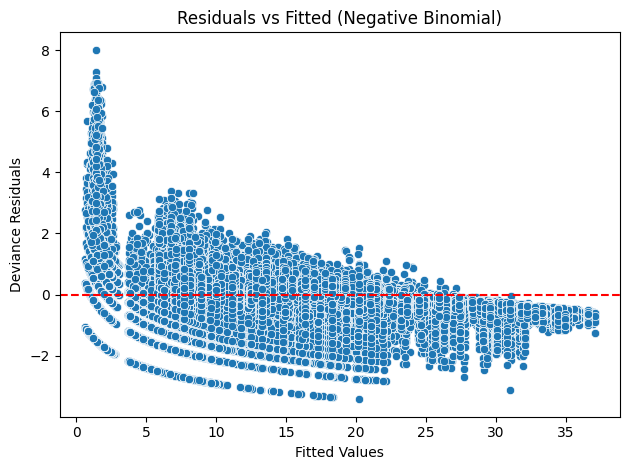

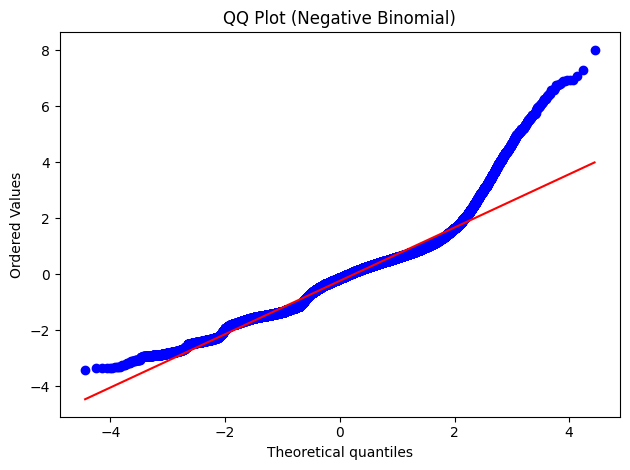

In [11]:
plt.figure()
sns.scatterplot(x=model_nb.fittedvalues, y=model_nb.resid_deviance)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Negative Binomial)")
plt.tight_layout()
plt.show()

# QQ Plot
plt.figure()
stats.probplot(model_nb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Negative Binomial)")
plt.tight_layout()
plt.show()

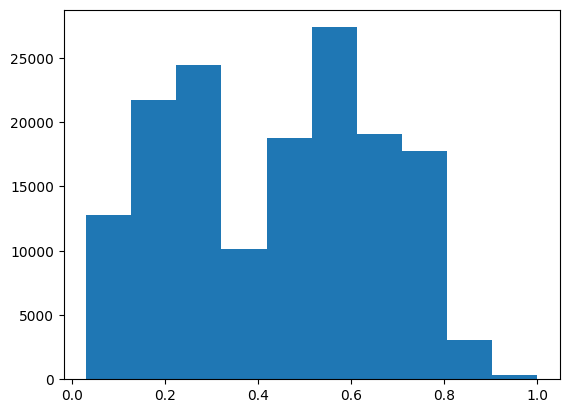

0         288
1         288
2         288
3         288
4         288
         ... 
155515    288
155516    288
155517    288
155518    288
155519    288
Name: space_occupied_N, Length: 155520, dtype: int64

In [12]:
df['space_occupied_norm'] = df['space_occupied'] / np.max(df["space_occupied"])  # Normalized space
df['space_occupied_N'] = np.max(df["space_occupied"]) # maximum of space occupied
plt.hist(df["space_occupied_norm"])
plt.show()
df["space_occupied_N"]

In [13]:
formula_bb = """
space_occupied_norm ~ BAT_SPEED + CALL_DURATION + CALL_RATE_FAST +
HEARING_THRESHOLD + CALL_DIRECTIONALITY + TEMPORAL_MASKING_FN_TYPE_ONE_HOT +
TIME_DELAY_FOR_DIRECTION_CHANGE + BAT_RADIAL_RESOLUTION +
MEMORY_WINDOW_FOR_CONSISTENCY + BAT_FRONTAL_RANGE
"""

model_bb = smf.glm(
    formula=formula_bb,
    data=df,
    family=sm.families.Binomial(),
    var_weights=df['space_occupied_N']
).fit()

# Print summary
print("BETA-BINOMIAL APPROXIMATION (SPACE OCCUPIED)")
print(model_bb.summary())



BETA-BINOMIAL APPROXIMATION (SPACE OCCUPIED)
                  Generalized Linear Model Regression Results                  
Dep. Variable:     space_occupied_norm   No. Observations:               155520
Model:                             GLM   Df Residuals:                   155509
Model Family:                 Binomial   Df Model:                           10
Link Function:                   Logit   Scale:                          1.0000
Method:                           IRLS   Log-Likelihood:            -1.7946e+07
Date:                 Thu, 12 Mar 2026   Deviance:                   1.2118e+06
Time:                         18:17:44   Pearson chi2:                 1.24e+06
No. Iterations:                      5   Pseudo R-squ. (CS):              1.000
Covariance Type:             nonrobust                                         
                                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

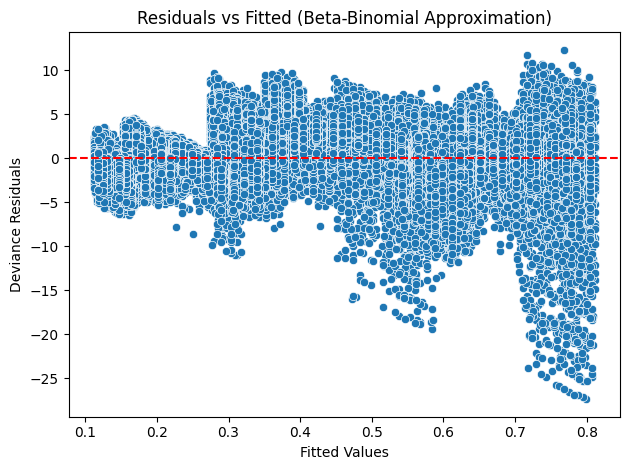

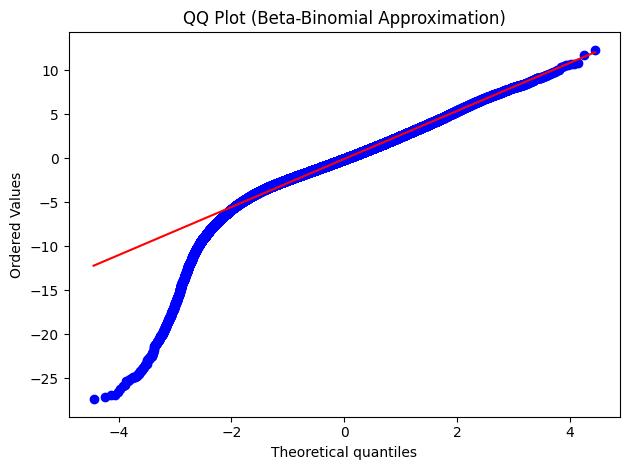

In [14]:
plt.figure()
sns.scatterplot(x=model_bb.fittedvalues, y=model_bb.resid_deviance)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Deviance Residuals")
plt.title("Residuals vs Fitted (Beta-Binomial Approximation)")
plt.tight_layout()
plt.show()

# QQ Plot
plt.figure()
stats.probplot(model_bb.resid_deviance, dist="norm", plot=plt)
plt.title("QQ Plot (Beta-Binomial Approximation)")
plt.tight_layout()
plt.show()



In [15]:
labels = np.array(['bat speed', 'call duration', 'fast call rate', 'hearing threshold', 'call directionality', 'temporal masking function', 'time spent listening', 'distance resolution', 'memory window size', 'frontal range'])


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (15,) and arg 3 with shape (10,).

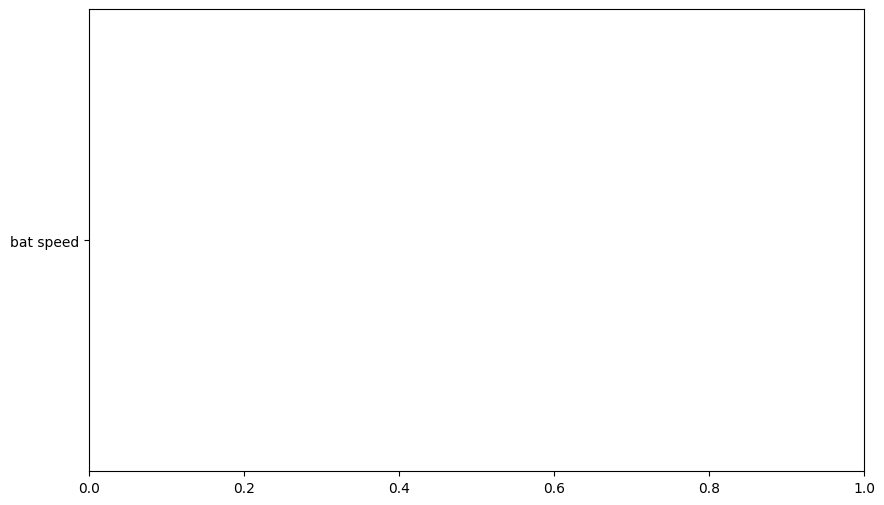

In [16]:
nb_coef = model_nb.params[1:]  # Negative Binomial (skip intercept)
bb_coef = model_bb.params[1:]  # Beta-Binomial (skip intercept)
# bb_coef = bb_coef
# %% [markdown]
# ## 1. Parameter Effects (Scaled)

# %%
# Plot for Negative Binomial (Collision Counts)
plt.figure(figsize=(10, 6))
effects = np.exp(nb_coef) - 1  # Center at 1 (rate ratio)
hbars = plt.barh(labels, effects, color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Negative Binomial: Change in Rate Ratio, on centered data')
plt.xlabel('Change from Baseline (Rate Ratio - 1)')
plt.tight_layout()
# plt.title("Incidence Rate Ratio, on centered data")
plt.show()
plt.figure(figsize=(10, 6))
effects = np.exp(bb_coef)-1 # Center at 0.5 (probability)
hbars = plt.barh(labels, effects,  color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Beta-Binomial: Change in Odds ratio, on centered data')
plt.xlabel('Change from 1 (Probability - 1)')
plt.tight_layout()
plt.show()


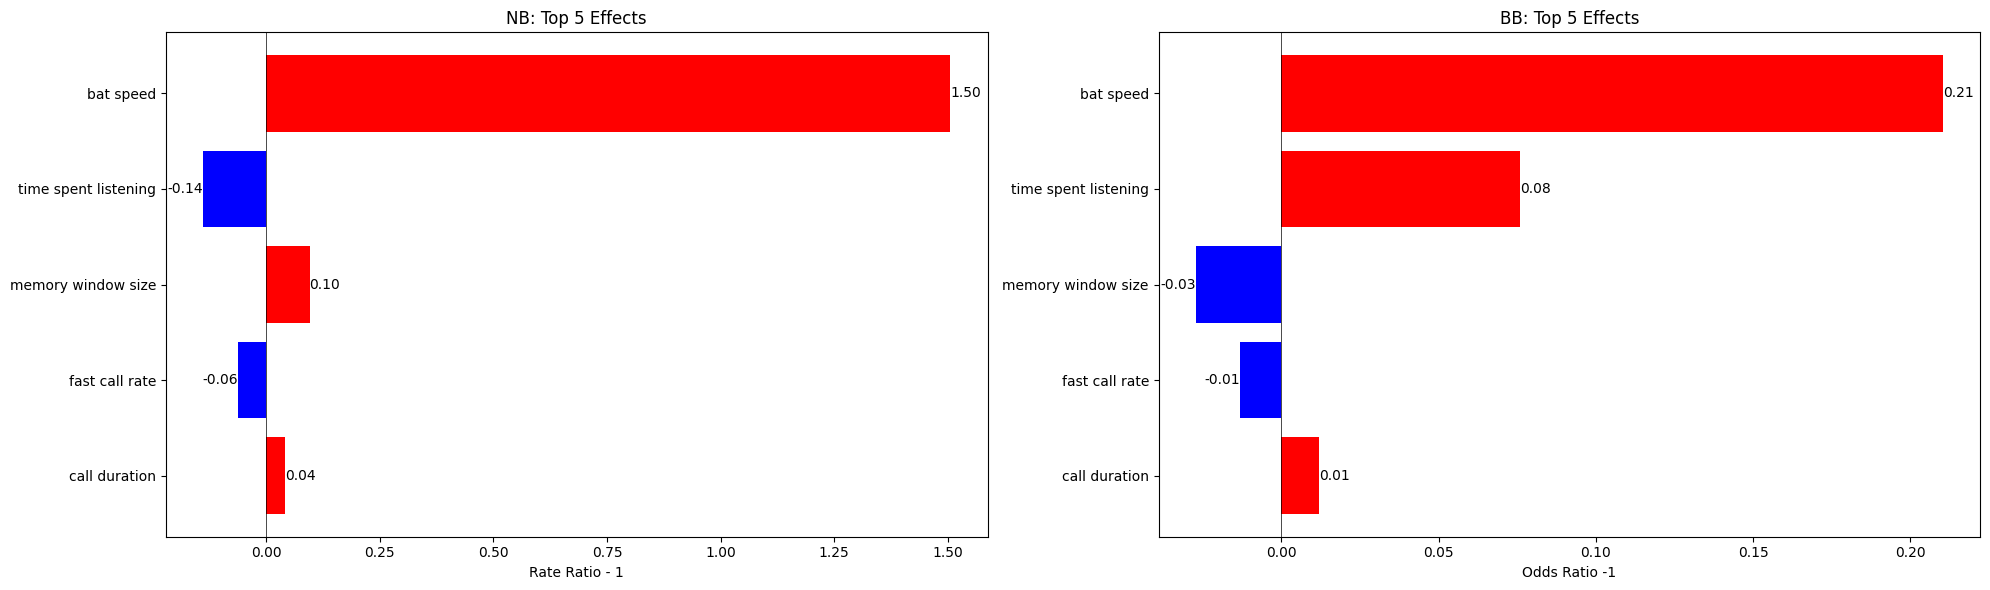

In [ ]:
plt.figure(figsize=(20, 6))
top_params = nb_coef.abs().sort_values().tail(5).index  # Top 5 parameters
subset_labels = []
for i in nb_coef.abs().sort_values().tail(5).index:
    subset_labels.append(labels[list(nb_coef.keys()).index(i)])

plt.subplot(1, 2, 1)
nb_effects = np.exp(nb_coef[top_params]) - 1
hbars = plt.barh(subset_labels, nb_effects, color=np.where(nb_effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('NB: Top 5 Effects')
plt.xlabel('Rate Ratio - 1')

top_params = bb_coef.abs().sort_values().tail(5).index 
subset_labels = []
for i in nb_coef.abs().sort_values().tail(5).index:
    subset_labels.append(labels[list(nb_coef.keys()).index(i)])
    
plt.subplot(1, 2, 2)
bb_effects = expit(bb_coef[top_params]) - 0.5
hbars= plt.barh(subset_labels, bb_effects, color=np.where(bb_effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('BB: Top 5 Effects')
plt.xlabel('Odds Ratio -1')

plt.tight_layout()
plt.show()

In [ ]:
subset_labels = []
for i in nb_coef.abs().sort_values().tail(5).index:
    subset_labels.append(labels[list(nb_coef.keys()).index(i)])
subset_labels

[np.str_('call duration'),
 np.str_('fast call rate'),
 np.str_('memory window size'),
 np.str_('time spent listening'),
 np.str_('bat speed')]

In [ ]:
def create_units_dict(df_overall_model, varying_params):
    units_dict = {}
    for param in varying_params:
        x= np.sort(np.unique(df_overall_model[param]))
        if len(x)<=2:
            unit = x[1] - x[0]
        else:
            unit = (x-np.mean(x))[-1]
        units_dict[param] = unit
    return units_dict

In [ ]:
import numpy as np
import pandas as pd
from scipy.special import expit, logsumexp

# Define parameters and original data
predictors = ['BAT_SPEED', 'CALL_DURATION', 'CALL_RATE_FAST', 'HEARING_THRESHOLD',
              'CALL_DIRECTIONALITY', 'TIME_DELAY_FOR_DIRECTION_CHANGE',
              'BAT_RADIAL_RESOLUTION', 'MEMORY_WINDOW_FOR_CONSISTENCY', 'BAT_FRONTAL_RANGE']

stds = df_overall_model[predictors].std()

def calculate_effects(model, model_type, units_dict):
    results = []
    intercept = model.params['Intercept']

    for param in predictors:
        scaled_coef = model.params[f'{param}']
        original_coef = scaled_coef / stds[param]
        baseline_rate = np.exp(intercept)

        rate_ratio_1unit = np.exp(original_coef)
        rate_ratio_xunit = np.exp(original_coef*units_dict[param])

        new_rate_1unit = baseline_rate * rate_ratio_1unit
        new_rate_xunits = baseline_rate * rate_ratio_xunit

        results.append({
            'Parameter': labels[list(varying_params).index(param)],
            'Original_Coef': original_coef,
            'Rate_Ratio_1unit': rate_ratio_1unit,
            'Rate_Ratio_xunit': rate_ratio_xunit,
            'Baseline_Rate': baseline_rate,
            'New_Rate_1unit': new_rate_1unit,
            'New_Rate_xunit': new_rate_xunits
        })


    return pd.DataFrame(results)

units_dict = create_units_dict(df_overall_model, predictors)
# Calculate effects for both models
nb_effects = calculate_effects(model_nb, 'nb', units_dict)
bb_effects = calculate_effects(model_bb, 'bb', units_dict)

In [ ]:
nb_effects

,Parameter,Original_Coef,Rate_Ratio_1unit,Rate_Ratio_xunit,Baseline_Rate,New_Rate_1unit,New_Rate_xunit
0,bat speed,0.562292,1.754689,3.078933,6.117371,10.734084,18.834980
1,call duration,0.027594,1.027978,1.086304,6.117371,6.288523,6.645325
2,fast call rate,-0.012855,0.987227,0.879366,6.117371,6.039234,5.379410
3,hearing threshold,0.001960,1.001962,1.039985,6.117371,6.129375,6.361975
4,call directionality,0.008685,1.008722,1.026396,6.117371,6.170729,6.278845
5,time spent listening,-0.019774,0.980420,0.820582,6.117371,5.997594,5.019807
6,distance resolution,0.006713,1.006735,1.013516,6.117371,6.158574,6.200055
7,memory window size,0.031119,1.031609,1.132557,6.117371,6.310734,6.928270
8,frontal range,0.001223,1.001224,1.037380,6.117371,6.124859,6.346038


In [ ]:
bb_effects

,Parameter,Original_Coef,Rate_Ratio_1unit,Rate_Ratio_xunit,Baseline_Rate,New_Rate_1unit,New_Rate_xunit
0,bat speed,0.549227,1.731915,2.999528,0.745281,1.290763,2.235492
1,call duration,0.031729,1.032238,1.099865,0.745281,0.769307,0.819709
2,fast call rate,-0.002364,0.997638,0.976633,0.745281,0.743521,0.727866
3,hearing threshold,0.018770,1.018948,1.455580,0.745281,0.759402,1.084816
4,call directionality,0.008733,1.008771,1.026546,0.745281,0.751818,0.765065
5,time spent listening,-0.014520,0.985585,0.864849,0.745281,0.734538,0.644556
6,distance resolution,-0.013867,0.986229,0.972648,0.745281,0.735018,0.724896
7,memory window size,0.003144,1.003149,1.012654,0.745281,0.747628,0.754712
8,frontal range,-0.002155,0.997848,0.937401,0.745281,0.743677,0.698628


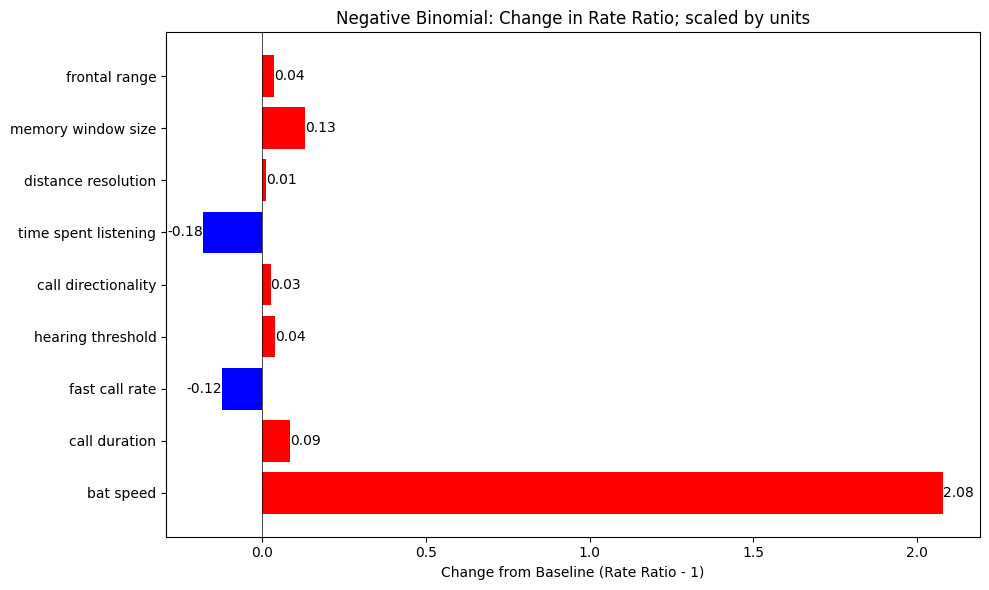

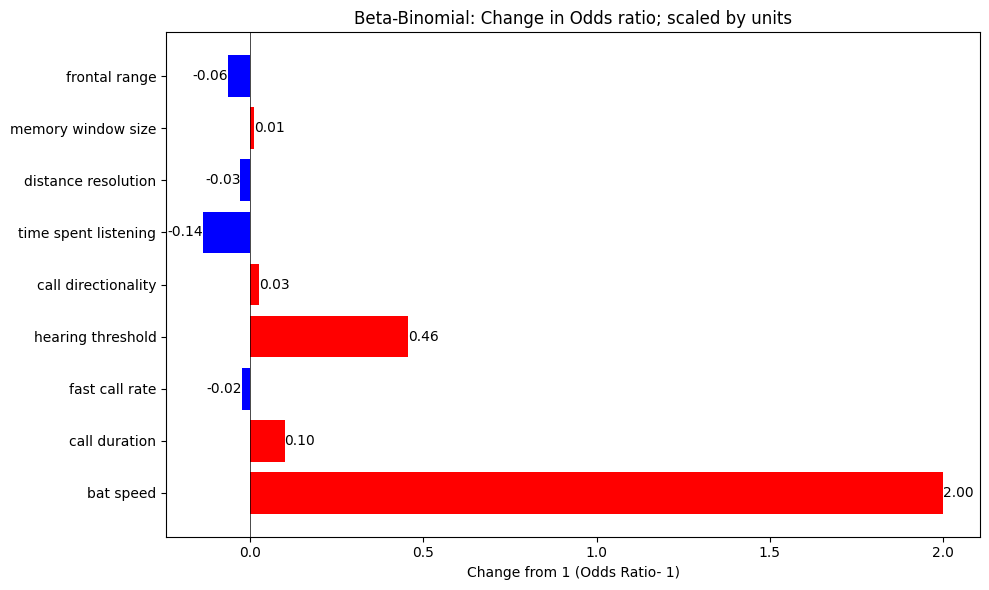

In [ ]:
plt.figure(figsize=(10, 6))
effects = nb_effects["Rate_Ratio_xunit"] -1
hbars = plt.barh(nb_effects["Parameter"], effects, color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Negative Binomial: Change in Rate Ratio; scaled by units')
plt.xlabel('Change from Baseline (Rate Ratio - 1)')
plt.tight_layout()
plt.show()
plt.figure(figsize=(10, 6))
effects = bb_effects["Rate_Ratio_xunit"] -1
hbars = plt.barh(bb_effects["Parameter"],effects,  color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('Beta-Binomial: Change in Odds ratio; scaled by units')
plt.xlabel('Change from 1 (Odds Ratio- 1)')
plt.tight_layout()
plt.show()


Index([4, 8, 3, 1, 2, 7, 5, 0], dtype='int64')


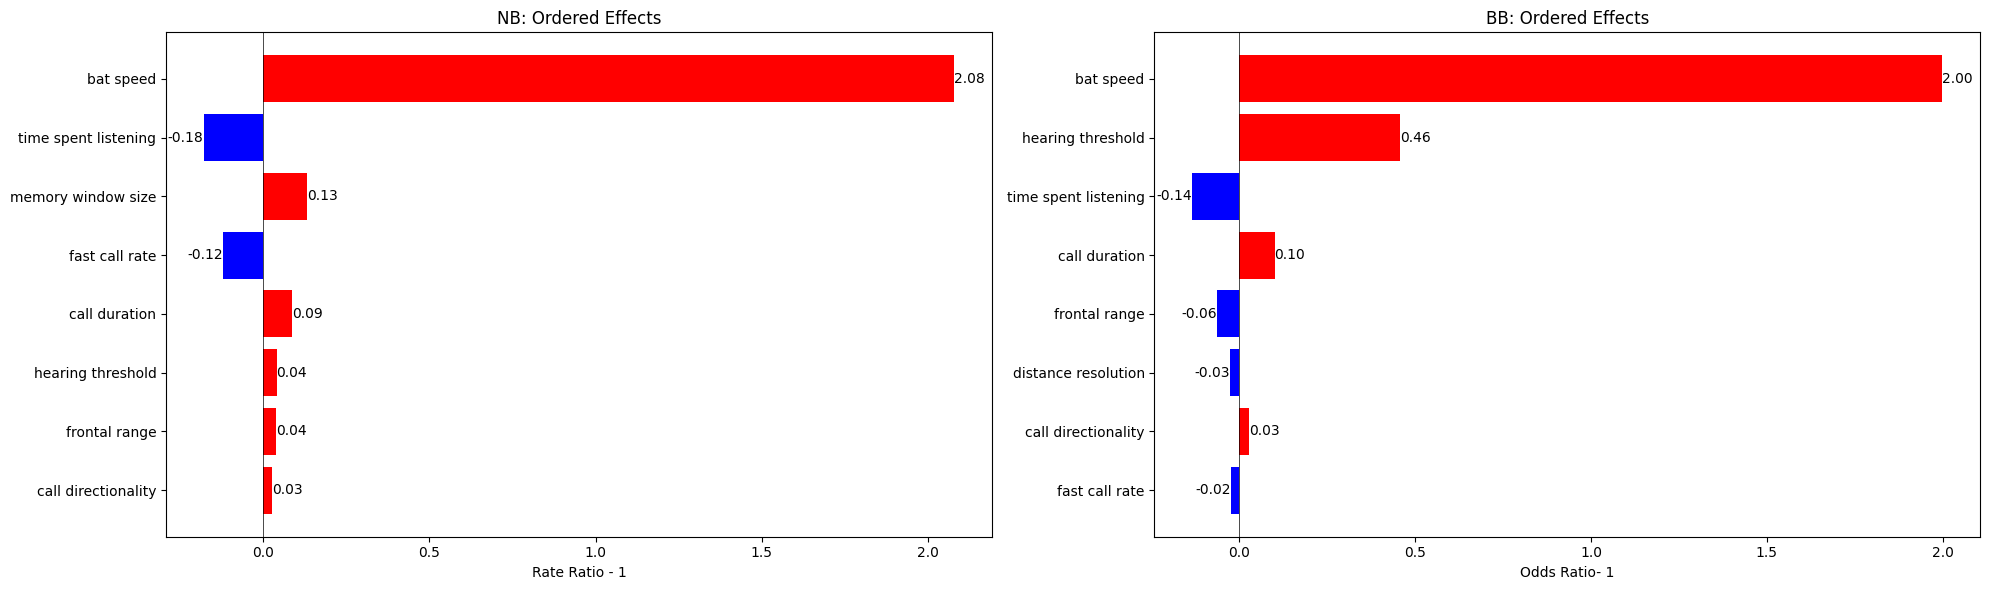

In [ ]:
plt.figure(figsize=(20, 6))
top_params = (nb_effects["Rate_Ratio_xunit"]-1).abs().sort_values().tail(-1).index  # Top 5 parameters
print(top_params)
plt.subplot(1, 2, 1)
# nb_effects = np.exp(nb_coef[top_params]) - 1
effects = nb_effects["Rate_Ratio_xunit"][top_params]-1

hbars = plt.barh(nb_effects["Parameter"][top_params], effects, color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('NB: Ordered Effects')
plt.xlabel('Rate Ratio - 1')

top_params = (bb_effects["Rate_Ratio_xunit"]-1).abs().sort_values().tail(-1).index 
plt.subplot(1, 2, 2)

effects = bb_effects["Rate_Ratio_xunit"][top_params]-1
hbars = plt.barh(bb_effects["Parameter"][top_params], effects, color=np.where(effects > 0, 'red', 'blue'))
plt.bar_label(hbars, fmt='%.2f')
plt.axvline(0, color='black', linewidth=0.5)
plt.title('BB: Ordered Effects')
plt.xlabel('Odds Ratio- 1')

plt.tight_layout()
plt.show()

In [ ]:
top_params = (nb_effects["Rate_Ratio_xunit"]-1).abs().sort_values().tail(-1).index 
for i, param in top_params:
    plt.subplot(3)